In [1]:
import os
import sys
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import tensorflow as tf

import os
from pathlib import Path

root = Path.cwd().resolve()
if not (root / "src").is_dir():
    os.chdir(root.parent)

from src.dataset.dice_detection.custom_dice_dataset import CustomDiceDataset

2026-05-28 14:16:23.891278: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-28 14:16:23.904573: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-05-28 14:16:23.919529: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8473] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-05-28 14:16:23.924248: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1471] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-05-28 14:16:23.936812: I tensorflow/core/platform/cpu_feature_guar

In [2]:
ROOT_DIR = "../datasets/s7dataset-2-dice-detection"
if not os.path.exists(ROOT_DIR):
    ROOT_DIR = "/workspace/datasets/s7dataset-2-dice-detection"

print(f"Loading from: {os.path.abspath(ROOT_DIR)}")
dataset_manager = CustomDiceDataset(ROOT_DIR)
print(f"Total samples: {len(dataset_manager.samples)}")

# Get the TF Dataset
batch_size = 16
ds = dataset_manager.get_tf_dataset(
    image_size=(640, 480),
    colored=True,
    augment=True,
    repeat=1,
    cache_path="../output/cache/test_v2" 
)

ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
data_iter = iter(ds)

Loading from: /workspace/datasets/s7dataset-2-dice-detection


I0000 00:00:1779977786.427234   31390 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1779977786.486167   31390 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1779977786.486215   31390 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1779977786.488534   31390 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1779977786.488579   31390 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:0

Total samples: 693


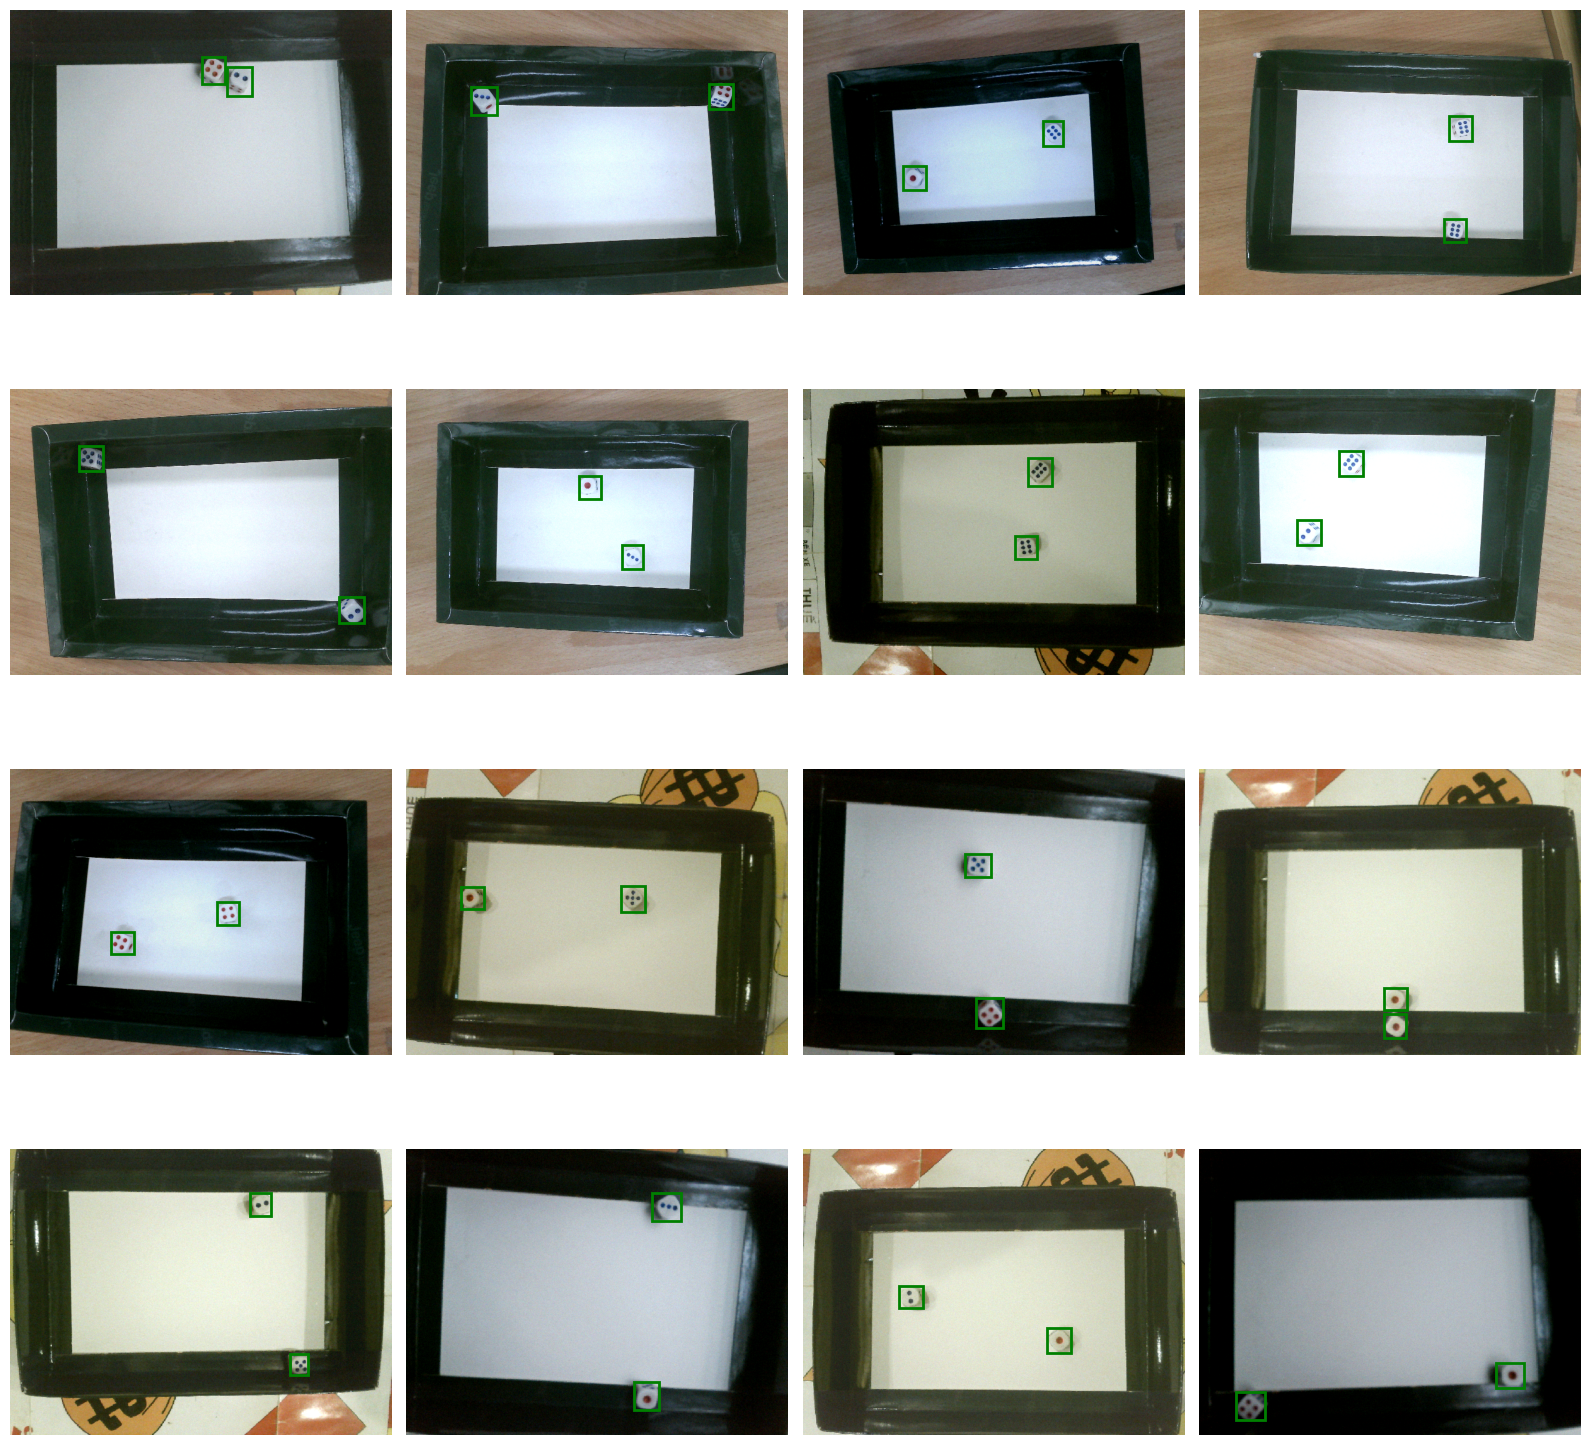

In [7]:
try:
    images, targets = next(data_iter)
    bboxes_batch = targets["boxes"]
    
    fig, axes = plt.subplots(4, 4, figsize=(16, 16))
    axes = axes.flatten()
    
    for i in range(16):
        if i >= len(images):
            axes[i].axis('off')
            continue
            
        img = images[i].numpy()
        axes[i].imshow(img)

        img_bboxes = bboxes_batch[i]
        if hasattr(img_bboxes, "to_tensor"):
             img_bboxes = img_bboxes.to_tensor()
             
        for box in img_bboxes.numpy():
            if np.all(box == 0): continue
            x, y, w, h = box
            rect = patches.Rectangle((x, y), w, h, linewidth=2, edgecolor='g', facecolor='none')
            axes[i].add_patch(rect)
            
        axes[i].axis('off')
        
    plt.tight_layout()
    plt.show()
except StopIteration:
    print("End of dataset reached. Re-run the initialization cell to restart.")